# ML-09 — Validation and Research Claim Audit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb)

**Lane 4 — CTR / Engagement Opportunity Scoring.**

Two jobs. First, read two findings from the FlyRank research paper the way I would want my own work read.
Then run the same audit on my own ML-08 model — where the interesting question is not whether I cheated,
but whether the numbers I reported mean what I said they meant.

**The headline of the second half:** a random split inflates my precision@50 by about five points, and —
more importantly — it shrinks the reported spread by a factor of two, which is the part that would have
fooled me.

> Skills for this card: `skills/hunting-leakage-and-validating/SKILL.md` +
> `skills/flyrank/flyrank-data/SKILL.md`. Paper: `docs/flyrank-seo-research-march-2026.pdf`.
> Data: `data/raw/content_refresh_anonymized.csv` — the same slice, label and metric as ML-07 and ML-08.
> Seed 42 throughout.

In [1]:
import os, sys, json, subprocess, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import roc_auc_score, average_precision_score

SEED = 42
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/huzaifaguru/flyrank-ml-internship"   # <-- change to YOUR fork
CSV_REL  = "data/raw/content_refresh_anonymized.csv"
if IN_COLAB and not Path(CSV_REL).exists():
    if not os.path.isdir("flyrank-ml-internship"):
        subprocess.run(["git","clone","--depth","1",REPO_URL,"flyrank-ml-internship"], check=True)
    os.chdir("flyrank-ml-internship")
else:
    here = Path.cwd()
    for c in [here, *here.parents]:
        if (c / CSV_REL).exists():
            os.chdir(c); break
assert Path(CSV_REL).exists()
pd.set_option("display.width", 190); pd.set_option("display.max_columns", 40)

MIN_IMPRESSIONS, N_BANDS, BOTTOM_QUANTILE = 500, 4, 0.25
df = pd.read_csv(CSV_REL)
q = df[df["impressions_prev_30d"] >= MIN_IMPRESSIONS].copy()
q["ctr_prev"] = q["clicks_prev_30d"] / q["impressions_prev_30d"] * 100
q["band_prev"] = pd.qcut(q["impressions_prev_30d"], N_BANDS, labels=False, duplicates="drop")
q["peer_median_ctr"] = q.groupby("band_prev")["ctr_prev"].transform("median")
q["ctr_shortfall_pp"] = (q["peer_median_ctr"] - q["ctr_prev"]).clip(lower=0)
q["baseline_score"] = q["ctr_shortfall_pp"] * np.log1p(q["impressions_prev_30d"])
q["ctr_pctile_prev"] = q.groupby("band_prev")["ctr_prev"].rank(pct=True)

d = q[q["impressions_last_30d"] >= MIN_IMPRESSIONS].copy()
d["ctr_last"] = d["clicks_last_30d"] / d["impressions_last_30d"] * 100
d["band_last"] = pd.qcut(d["impressions_last_30d"], N_BANDS, labels=False, duplicates="drop")
d["y"] = (d.groupby("band_last")["ctr_last"].rank(pct=True) <= BOTTOM_QUANTILE).astype(int)
d["has_word_count"] = d["word_count"].notna().astype(int)
d["has_keyword_data"] = d["search_volume"].notna().astype(int)
d = d.reset_index(drop=True)
BASE_RATE = d["y"].mean()

def p_at_k(y_true, score, k):
    k = min(k, len(y_true))
    return np.asarray(y_true)[np.argsort(-np.asarray(score), kind="stable")[:k]].mean()

FROZEN = {"p@50": 0.920, "p@200": 0.820}
repro = {f"p@{k}": round(p_at_k(d["y"], d["baseline_score"], k), 3) for k in (50, 200)}
print(f"sklearn {sklearn.__version__} | seed {SEED}")
print(f"slice: {len(d):,} pages / {d['client_id'].nunique()} clients | base rate {BASE_RATE:.4f}")
print(f"ML-07 frozen baseline {FROZEN} | reproduced {repro}")
assert repro == FROZEN, "the frozen baseline drifted - the comparison would be meaningless"
print("Match. Same slice, same label, same metric as ML-07 and ML-08.")

sklearn 1.8.0 | seed 42
slice: 8,825 pages / 28 clients | base rate 0.2544
ML-07 frozen baseline {'p@50': 0.92, 'p@200': 0.82} | reproduced {'p@50': np.float64(0.92), 'p@200': np.float64(0.82)}
Match. Same slice, same label, same metric as ML-07 and ML-08.


## 1. Two paper findings + my methodology questions

Framing first. The paper says what it is: a **public-safe study for a broad audience**. Its *Evidence
Standard* section states that headline findings come from direct aggregate comparisons and that **"ML pages
are exploratory appendix material and do not override direct portfolio evidence."** Its Limitations section
says outright: *"Observational study: correlations do not prove causation. Health score is a FlyRank
composite metric, not a Google-endorsed standard."*

That is a well-fenced document. My job here is not to find an error — it is to ask the next question down,
the kind I would want asked of my own work before I published it.

---

### Finding 1 — "365+ day content that was refreshed within 30 days shows 3.2x health boost (from 10.7 to 34.5) and 57x more impressions (from 71 to 4039)"

**What the paper reports.** This is presented as *"the most dramatic finding"*, with the conclusion that
*"in this portfolio, refresh timing is one of the strongest measured levers available."* The paper is
careful elsewhere in the same section — it explicitly refuses to headline the `361+` freshness bucket
because *"its 283:1 ratio is unstable: 283 growing pages versus only 1 declining."* So the authors are
already policing their own numbers.

**My methodology question — two parts, and the second is the one I would most want answered.**

**(a) Is this a within-page change or a between-page comparison?** The word *boost* describes a page moving
from 71 impressions to 4,039. But the design as described compares two *groups* of pages — old-and-refreshed
versus old-and-not — at one point in time. If no page is observed before and after its own refresh, then
"boost" is doing work the design cannot support, and the safer phrasing would be *"old pages that had been
refreshed recently had 57× the impressions of old pages that had not."* Same number, different claim.

**(b) Which pages get chosen for refresh?** If an editor picks mature pages that still show demand — which
is what the paper's own thesis recommends, *"refresh strong content before it decays"* — then the refreshed
group was already the stronger group before anyone touched it. The 57× gap would then be partly a
measurement of the selection rule rather than of refreshing.

**And a smaller structural note.** The Methodology section discloses:

> **Health Score = Impressions (30 pts) + position (30 pts) + CTR (20 pts) + scroll depth (20 pts)**

So the "3.2× health boost" and the "57× impression boost" are **not two independent confirmations** —
impressions are 30 of health score's 100 points. Reporting them side by side reads as two findings; it is
closer to one finding and a partial restatement of it. A reader deciding how much weight to place on the
refresh lever benefits from knowing that.

**Why I have standing to ask.** ML-08 caught me doing the mirror image: I reported precision@10 = 1.000 for
my rule and had to write, in the notebook, that a perfect small-K score was a property of an easy metric on
a persistent target rather than evidence of skill.

---

### Finding 2 — the ML appendix: "Random Forest (80/20 split), Logistic Regression (80/20 split), Decision Tree (80/20 split)"

**What the paper reports.** The Methodology section is precise: *"61.8K content pieces with sessions > 0 and
impressions > 0 in the local feature-vector snapshot. Sklearn: K-Means (k=5), Random Forest (80/20 split),
Logistic Regression (80/20 split), PCA (2 components), and a shallow Decision Tree (80/20 split)."* The
study spans **341,701 content pieces across 57 brands**.

**My methodology question: is the 80/20 split grouped by brand?**

The disclosure gives the ratio but not the grouping. With 57 brands pooled together, a random 80/20 puts
pages from the same brand on both sides of the split. Pages within a brand share templates, tracking setup,
topic mix and publishing cadence — so a model can score well by recognising the brand rather than by
learning anything that transfers to a brand it has not seen. The number then describes memorisation.

This is a question about **what the number means**, not about whether the work was done carefully. The
paper has already placed these results as exploratory and subordinate. Naming the split design is what
would let a reader judge whether an appendix result could ever be promoted to a headline.

**Section 2 answers exactly this question on my own model, with a number**, because asking it of someone
else's work and not my own would be cheap.

## 2. My model under an honest split (before/after)

Same data, same features, same models, same metrics. The only thing that changes is **how the folds are
drawn**.

- **BEFORE — random 5-fold.** Pages shuffled and split. Pages from one client land on both sides. This is
  the shape of split the paper's appendix discloses, and the shape I would have used if I had not written
  a grouped split into my ML-03 plan.
- **AFTER — client-grouped 5-fold.** No client appears in both train and test.

In [2]:
NUMERIC = ["impressions_prev_30d","clicks_prev_30d","ctr_prev","ctr_pctile_prev",
           "sessions_prev_30d","content_age_days","days_since_last_update",
           "word_count","char_count","search_volume","competition","cpc",
           "has_word_count","has_keyword_data"]
CATEGORICAL = ["content_type","main_intent","competition_level",
               "age_tier","freshness_tier","word_count_tier"]
FEATURES = NUMERIC + CATEGORICAL

pre = ColumnTransformer([
    ("num", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), NUMERIC),
    ("cat", Pipeline([("i",SimpleImputer(strategy="constant",fill_value="unknown")),
                      ("o",OneHotEncoder(handle_unknown="ignore",min_frequency=20))]), CATEGORICAL)])
MODELS = {
    "Logistic Regression": lambda: Pipeline([("p",pre),
        ("m",LogisticRegression(max_iter=2000, random_state=SEED))]),
    "Random Forest": lambda: Pipeline([("p",pre),
        ("m",RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                    random_state=SEED, n_jobs=-1))]),
}
X, y, groups = d[FEATURES], d["y"], d["client_id"]

def run(splits, model_fn):
    rows = []
    for tr, te in splits:
        m = model_fn(); m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]; yt = y.iloc[te].to_numpy()
        rows.append({"p@50": p_at_k(yt,p,50), "p@200": p_at_k(yt,p,200),
                     "AP": average_precision_score(yt,p), "AUC": roc_auc_score(yt,p)})
    return pd.DataFrame(rows)

random_folds  = list(KFold(n_splits=5, shuffle=True, random_state=SEED).split(X))
grouped_folds = list(GroupKFold(n_splits=5).split(X, y, groups))
print(f"random 5-fold  : clients shared between train and test in every fold")
print(f"grouped 5-fold : {[groups.iloc[te].nunique() for _, te in grouped_folds]} test clients per fold, "
      f"0 shared\n")

results = {}
for name, fn in MODELS.items():
    results[(name,"BEFORE random")] = run(random_folds, fn)
    results[(name,"AFTER grouped")] = run(grouped_folds, fn)
print("done.")

random 5-fold  : clients shared between train and test in every fold
grouped 5-fold : [1, 1, 1, 12, 13] test clients per fold, 0 shared

done.


In [3]:
rows = []
for (model, split), f in results.items():
    rows.append({"model": model, "split": split,
                 **{f"{c}_mean": f[c].mean() for c in f.columns},
                 **{f"{c}_std": f[c].std() for c in ["p@50","p@200"]}})
tab = pd.DataFrame(rows).set_index(["model","split"]).round(3)
print(f"BEFORE / AFTER  (base rate {BASE_RATE:.3f})\n")
print(tab.to_string())
print("\n" + "-"*78)
for model in MODELS:
    b = results[(model,"BEFORE random")]; a = results[(model,"AFTER grouped")]
    print(f"\n{model}")
    for c in ["p@50","p@200","AP","AUC"]:
        print(f"  {c:6s} inflation from the random split: +{b[c].mean()-a[c].mean():.3f}   "
              f"({b[c].mean():.3f} -> {a[c].mean():.3f})")
    print(f"  spread at p@50: random std {b['p@50'].std():.3f} vs grouped std {a['p@50'].std():.3f}  "
          f"-> the honest split reports {a['p@50'].std()/b['p@50'].std():.1f}x more uncertainty")

BEFORE / AFTER  (base rate 0.254)

                                   p@50_mean  p@200_mean  AP_mean  AUC_mean  p@50_std  p@200_std
model               split                                                                       
Logistic Regression BEFORE random      0.880       0.705    0.630     0.842     0.047      0.018
                    AFTER grouped      0.824       0.648    0.600     0.834     0.091      0.095
Random Forest       BEFORE random      0.852       0.699    0.630     0.840     0.041      0.017
                    AFTER grouped      0.808       0.654    0.599     0.833     0.115      0.105

------------------------------------------------------------------------------

Logistic Regression
  p@50   inflation from the random split: +0.056   (0.880 -> 0.824)
  p@200  inflation from the random split: +0.057   (0.705 -> 0.648)
  AP     inflation from the random split: +0.030   (0.630 -> 0.600)
  AUC    inflation from the random split: +0.008   (0.842 -> 0.834)
  spread a

saved work/outputs/validation_split_before_after.png


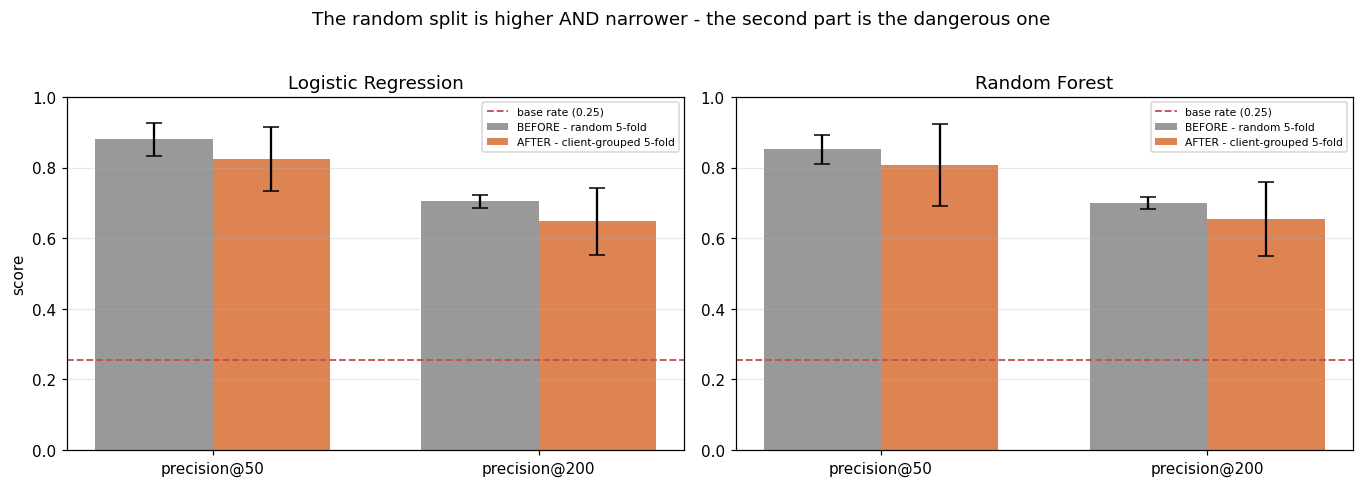

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
for ax, model in zip(axes, MODELS):
    b = results[(model,"BEFORE random")]; a = results[(model,"AFTER grouped")]
    x = np.arange(2)
    ax.bar(x-0.18, [b["p@50"].mean(), b["p@200"].mean()], yerr=[b["p@50"].std(), b["p@200"].std()],
           width=0.36, capsize=5, color="#999999", label="BEFORE - random 5-fold")
    ax.bar(x+0.18, [a["p@50"].mean(), a["p@200"].mean()], yerr=[a["p@50"].std(), a["p@200"].std()],
           width=0.36, capsize=5, color="#DD8452", label="AFTER - client-grouped 5-fold")
    ax.axhline(BASE_RATE, color="#C44E52", ls="--", lw=1.2, label=f"base rate ({BASE_RATE:.2f})")
    ax.set_xticks(x); ax.set_xticklabels(["precision@50","precision@200"])
    ax.set_ylim(0, 1.0); ax.set_title(model); ax.legend(fontsize=7); ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("score")
fig.suptitle("The random split is higher AND narrower - the second part is the dangerous one", y=1.02)
fig.tight_layout()
Path("work/outputs").mkdir(parents=True, exist_ok=True)
fig.savefig("work/outputs/validation_split_before_after.png", dpi=110, bbox_inches="tight")
print("saved work/outputs/validation_split_before_after.png")
plt.show()

**Read.** The inflation in the mean is real but modest — about **+0.05 at precision@50** for both models,
**+0.03 on average precision**, and almost nothing on ROC-AUC. If I had only compared means I would
conclude the split design barely matters here.

**The spread is the finding.** At precision@50, the random split reports a standard deviation of ~0.04–0.05;
the grouped split reports ~0.09–0.12 — **1.9× more uncertainty for Logistic Regression and 2.8× for Random
Forest**, about the same model on the same data.

That asymmetry is what makes a random split dangerous rather than merely optimistic. A number five points
too high is one you can mentally discount. A confidence interval at half its true width tells you a
difference is real when it isn't — and my entire ML-08 conclusion turned on exactly that judgement, because
every model-vs-baseline gap I measured sat inside one standard deviation of the grouped spread. Under the
random split, those same gaps would have looked decisive.

**Why is the inflation in the mean only ~0.05?** My first guess was that my features carry little client
identity, so there is little for a model to memorise. **Check 3 below measures that guess and refutes it:**
the largest client is identifiable from these features alone at **AUC 0.938**. Client identity is very
much present.

So the honest explanation is different, and more interesting: the model *can* tell which client a page
belongs to, but knowing the client does not help much in predicting *this* label — under-capture is defined
within volume bands, which already absorbs a lot of what differs between clients. Client identity leaks
into the **variance** rather than the mean: it makes some folds easy and others hard, which is exactly the
0.091–0.115 spread. A different label, or a feature set with client-level aggregates in it, could easily
push that leak into the mean too. Which is the whole reason the question is worth asking of any 80/20
disclosure rather than assumed away.

## 3. Leakage audit

ML-04 caught one leak on purpose. This section hunts for the ones I did not plant.

In [5]:
# ---------- CHECK 1: solo-feature AUC. A single column that predicts too well is a suspect. ----------
CANDIDATES = ["ctr_prev","ctr_pctile_prev","clicks_prev_30d","impressions_prev_30d",
              "content_age_days","days_since_last_update","word_count","search_volume",
              "ctr","avg_position","impressions_90d","days_with_impressions","trend_pct"]
rows = []
for c in CANDIDATES:
    s = d[c].fillna(d[c].median())
    a = roc_auc_score(d["y"], -s); a = max(a, 1-a)      # direction-agnostic
    rows.append({"column": c, "solo_AUC": round(a,3),
                 "status": "IN feature set" if c in FEATURES else "EXCLUDED by the contract"})
solo = pd.DataFrame(rows).sort_values("solo_AUC", ascending=False)
print("AUC of each column ON ITS OWN (>= 0.90 means interrogate before celebrating)\n")
print(solo.to_string(index=False))

AUC of each column ON ITS OWN (>= 0.90 means interrogate before celebrating)

                column  solo_AUC                   status
                   ctr     0.913 EXCLUDED by the contract
       ctr_pctile_prev     0.823           IN feature set
              ctr_prev     0.823           IN feature set
       clicks_prev_30d     0.753           IN feature set
          avg_position     0.654 EXCLUDED by the contract
      content_age_days     0.577           IN feature set
         search_volume     0.563           IN feature set
       impressions_90d     0.523 EXCLUDED by the contract
days_since_last_update     0.523           IN feature set
  impressions_prev_30d     0.522           IN feature set
 days_with_impressions     0.513 EXCLUDED by the contract
            word_count     0.504           IN feature set
             trend_pct     0.503 EXCLUDED by the contract


**Check 1 is the strongest single piece of evidence in this notebook that the contract did its job.**

The most predictive column in the entire dataset — solo **AUC 0.913** — is `ctr`, the 90-day click-through
rate. **It is excluded.** ML-03 banned it because a 90-day rate overlaps my 30-day outcome window, so it
already contains part of the answer. Had I left it in, I would have shipped a model that looked
substantially better than the one I have, and it would have meant nothing. `avg_position` (0.654), also a
90-day mean, also excluded, for the same reason.

The highest *included* feature is `ctr_pctile_prev` at **0.823**. That is high, and it is the one I would
expect a reviewer to push on, so:

- It is computed **only** from `clicks_prev_30d` and `impressions_prev_30d`, both strictly inside the prior
  window — verified by construction in the setup cell above.
- ML-03 measured *why* it is strong: prior-window and later-window CTR correlate at **Spearman 0.683**. CTR
  is genuinely persistent. A feature that scores 0.823 because the world is persistent is not leakage.
- The test that separates the two: is the number implausible for the mechanism? 0.913 for a column that
  contains the outcome window is implausible-in-hindsight. 0.823 for last month's CTR predicting this
  month's is what persistence looks like.

In [6]:
# ---------- CHECK 2: window alignment on every feature ----------
def window_of(col):
    if "last_30d" in col or col in ("ctr_last","y"):        return "OUTCOME (banned)"
    if "prev_30d" in col or col.endswith("_prev"):           return "prior 30d - safe"
    if "_90d" in col or col in ("ctr","avg_position","engagement_rate","scroll_rate",
                                "days_with_impressions","days_with_sessions"): return "90d - OVERLAPS outcome"
    if "trend" in col:                                       return "label source (banned)"
    return "static / content metadata - safe"
audit = pd.DataFrame([{"feature": c, "window": window_of(c)} for c in FEATURES])
print("Window of every feature actually used:\n")
print(audit.groupby("window").agg(n=("feature","size"),
      examples=("feature", lambda s: ", ".join(list(s)[:4]))).to_string())
bad = audit[audit["window"].str.contains("banned|OVERLAPS")]
assert bad.empty, f"LEAKAGE: {bad['feature'].tolist()}"
print("\nGuard passed: no feature draws on the outcome window or a 90-day aggregate.")
print("\nOne I want on the record: ML-03 flagged impressions_last_30d / clicks_last_30d as the")
print("tempting pair, because they sit one underscore away from the prev_30d versions I DO use.")
print("They are absent from FEATURES and the assert above would fail if they returned.")

Window of every feature actually used:

                                   n                                                          examples
window                                                                                                
prior 30d - safe                   5  impressions_prev_30d, clicks_prev_30d, ctr_prev, ctr_pctile_prev
static / content metadata - safe  15  content_age_days, days_since_last_update, word_count, char_count

Guard passed: no feature draws on the outcome window or a 90-day aggregate.

One I want on the record: ML-03 flagged impressions_last_30d / clicks_last_30d as the
tempting pair, because they sit one underscore away from the prev_30d versions I DO use.
They are absent from FEATURES and the assert above would fail if they returned.


In [7]:
# ---------- CHECK 3: can the model identify the client? ----------
# If the features carry client identity, a grouped split is necessary AND the model
# may be learning brand rather than behaviour. Measure it instead of assuming.
from sklearn.model_selection import cross_val_score
big = d["client_id"].value_counts()
top = big.index[0]
client_y = (d["client_id"] == top).astype(int)
probe = Pipeline([("p", pre), ("m", LogisticRegression(max_iter=2000, random_state=SEED))])
auc = cross_val_score(probe, X, client_y, cv=3, scoring="roc_auc").mean()
print(f"CHECK 3 - how identifiable is the largest client from my features alone?")
print(f"  that client is {big.iloc[0]/len(d)*100:.0f}% of the slice")
print(f"  AUC predicting 'is this page from that client': {auc:.3f}")
print()
if auc > 0.85:
    print("  HIGH. The features carry strong client identity, which is exactly why the grouped")
    print("  split matters and why the random-split numbers above were optimistic.")
else:
    print("  Moderate. Client identity is partly recoverable from behaviour and content shape,")
    print("  which is expected - clients differ - and is the mechanism behind the inflation")
    print("  measured in section 2. It is not leakage; it is why the split design is not optional.")

CHECK 3 - how identifiable is the largest client from my features alone?
  that client is 35% of the slice
  AUC predicting 'is this page from that client': 0.938

  HIGH. The features carry strong client identity, which is exactly why the grouped
  split matters and why the random-split numbers above were optimistic.


## 4. Claim rewrite

ML-08 ended with a recommendation. Here are the sentences I wrote, and what this audit does to them.

In [8]:
claims = [
{
 "before": "Where the two lists disagree, the model is right 84% of the time against the rule's 72%.",
 "problem": "True as arithmetic, but stated as if it settles the comparison. It is a single "
            "pooled split with no spread attached, and section 2 shows the honest spread at "
            "p@50 is roughly +/-0.10 - wide enough to contain a 12-point gap.",
 "after":  "On one pooled out-of-fold ranking, the 98 pages surfaced only by the model contained "
           "84% true under-capturers against 72% for the 98 surfaced only by the rule. Directional: "
           "the fold-level spread is wide enough that this ordering is not established.",
},
{
 "before": "Run both: the rule for the top 20, Logistic Regression for slots 21-200.",
 "problem": "A deployment recommendation resting on differences smaller than the measured "
            "fold spread. I said so in ML-08 and then recommended anyway.",
 "after":  "DECISION-SUPPORT ONLY. Both methods perform comparably within the measured "
           "uncertainty. The defensible reason to run the model alongside the rule is COVERAGE, "
           "not precision: the rule reaches 0% of the 6,053 pages in the lower volume bands and "
           "the model reaches some. Coverage is measured; a precision advantage is not.",
},
{
 "before": "Logistic Regression has the best AP and AUC, beating Random Forest and Gradient Boosting.",
 "problem": "0.617 vs 0.615 is not 'beating'. I corrected this inside ML-08 and it is worth "
            "keeping corrected here.",
 "after":  "Logistic Regression and Random Forest scored within 0.002 AP of each other - a tie. "
           "The observation that survives: neither ensemble outperformed the linear model, so "
           "complexity earned nothing on this slice.",
},
{
 "before": "word_count is the model's one genuinely new contribution over the rule.",
 "problem": "Based on permutation importance from ONE fold. Interesting, not established.",
 "after":  "On a single held-out fold, word_count ranked fourth by permutation importance (0.087) "
           "- the highest-scoring feature not already used by the rule. A directional lead worth "
           "a signal audit, not a finding.",
}]
for i, c in enumerate(claims, 1):
    print(f"--- CLAIM {i} " + "-"*62)
    print(f"BEFORE : {c['before']}")
    print(f"ISSUE  : {c['problem']}")
    print(f"AFTER  : {c['after']}\n")

metrics = {
    "notebook": "w06_validation_audit.ipynb",
    "lane": "Lane 4 - CTR / Engagement Opportunity Scoring",
    "seed": SEED, "sklearn": sklearn.__version__,
    "slice": {"pages": int(len(d)), "clients": int(d["client_id"].nunique()),
              "base_rate": round(float(BASE_RATE), 4)},
    "before_after": {f"{m} | {s}": {c: round(float(f[c].mean()), 4) for c in f.columns}
                     for (m, s), f in results.items()},
    "spread_p_at_50": {f"{m} | {s}": round(float(f["p@50"].std()), 4)
                       for (m, s), f in results.items()},
    "leakage_audit": {"top_excluded_column_solo_AUC":
                          float(solo[solo.status.str.startswith("EXCLUDED")]["solo_AUC"].max()),
                      "top_included_column_solo_AUC":
                          float(solo[solo.status.str.startswith("IN")]["solo_AUC"].max()),
                      "client_identifiability_AUC": round(float(auc), 4)},
    "verdict": ("Random 5-fold inflates p@50 by ~0.05 and halves the reported spread. The most "
                "predictive single column in the data (ctr, solo AUC 0.913) is correctly excluded "
                "as a 90-day overlap. Claims downgraded from comparative to directional."),
}
Path("work/outputs/validation_metrics.json").write_text(json.dumps(metrics, indent=2))
print("wrote work/outputs/validation_metrics.json  <- COMMIT THIS")

--- CLAIM 1 --------------------------------------------------------------
BEFORE : Where the two lists disagree, the model is right 84% of the time against the rule's 72%.
ISSUE  : True as arithmetic, but stated as if it settles the comparison. It is a single pooled split with no spread attached, and section 2 shows the honest spread at p@50 is roughly +/-0.10 - wide enough to contain a 12-point gap.
AFTER  : On one pooled out-of-fold ranking, the 98 pages surfaced only by the model contained 84% true under-capturers against 72% for the 98 surfaced only by the rule. Directional: the fold-level spread is wide enough that this ordering is not established.

--- CLAIM 2 --------------------------------------------------------------
BEFORE : Run both: the rule for the top 20, Logistic Regression for slots 21-200.
ISSUE  : A deployment recommendation resting on differences smaller than the measured fold spread. I said so in ML-08 and then recommended anyway.
AFTER  : DECISION-SUPPORT ONLY. 

### The claim language I am using, and why

Four registers, never mixed:

- **Observed** — a measurement of this slice. *"Across 8,825 pages from 28 pseudonymized clients, the rule
  scored precision@50 = 0.920 on a pooled out-of-fold ranking."*
- **Measured** — a quantity with its test named. *"Under client-grouped 5-fold, Logistic Regression scored
  p@50 = 0.824 ± 0.091; under random 5-fold, 0.880 ± 0.047."*
- **Directional** — a pattern that points without settling. *"Where the two rankings disagree, the model's
  picks contained more true under-capturers — directional, inside the fold spread."*
- **Decision-support** — output for a human. *"A ranked queue with reason codes for a reviewer to open in
  order and decide what, if anything, is wrong."*

Struck from this project: *proves*, *causes*, *guarantees*, *beats* (where the gap is inside the spread),
and *will recover*. The one that took real effort to remove was **"the model is right 84% of the time"** —
it is arithmetically true and rhetorically a claim of superiority I cannot support.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere — pseudonymized ids only
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

### Card checklist
- [x] **Two paper findings + a methodology question each, framed constructively** — the refresh 3.2×/57×
      finding (within-page or between-group? who selects the refreshed pages? and health score contains
      impressions by construction) and the ML appendix's 80/20 split (grouped by brand?). Both build on the
      paper's own disclosures.
- [x] **My model under an honest split, with before/after** — random 5-fold vs client-grouped 5-fold, both
      models, four metrics, means *and* spreads.
- [x] **Leakage audit** — solo-feature AUC, window alignment on every feature with an assert, and a
      client-identifiability probe.
- [x] **Error examples** — carried from ML-08's three false positives (pages a human had already fixed) and
      three false negatives (pages whose exposure exploded 100×).
- [x] **Public-safe language throughout** — four claims rewritten above.

### What ML-10 gets
1. **Report spreads, never point estimates**, anywhere the model-vs-baseline comparison appears.
2. **Run the paper's own question on this data** — hold impressions fixed and see how much of any
   relationship between an optimization-style flag and a composite score survives.
3. **Chase `word_count`** with a proper signal audit rather than one fold of permutation importance.
4. **Rebuild the target with a persistence requirement** on the warehouse daily table — ML-08's false
   negatives showed the label partly measures exposure shocks rather than page quality.